# 03b. Three deeper looks at the finished model

*Rent Reality Check (London). Created by Kevin Steepan.*

---

## What this is

Notebook 03 built and checked the price model. This is an optional appendix with
three deeper looks that would have made that notebook too long:

1. **Partial dependence and ICE plots.** SHAP told us, for one listing, how much
   each feature moved its price. These plots answer a different question: across
   all listings, what is the *shape* of the relationship between a feature and the
   price?
2. **Which listings does the model most disagree with?** Running the model over
   every listing and looking at the biggest gaps in each direction, first raw and
   then with a filter for plausible listings.
3. **Why is Brent hard?** Notebook 03's fairness check flagged Brent as the one
   well-sampled borough the model predicts badly. This is a short, honest attempt
   to work out why.

The first two load the saved model. Nothing is re-trained except a quick set of
cross-validation folds for parts 2 and 3.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from londonrent.features import build_model_frame
from londonrent import model as M
from londonrent.config import PROJECT_ROOT

# the cold-start feature set (no reviews), same as the shipped model
frame, groups = build_model_frame(with_reviews=False)
y = frame["log_price"].to_numpy()
bundle = M.load_bundle(PROJECT_ROOT / "models" / "price_model.joblib")
enc, gbr = bundle["encoder"], bundle["model"]
X = M.build_design_matrix(frame, groups, enc)
print(f"{len(frame):,} listings, design matrix {X.shape}")

59,450 listings, design matrix (59450, 72)


## Part 1. Partial dependence (PDP) and ICE

### The plain idea

Pick a feature, say "metres to the nearest station". Sweep it across its range. At
each swept value, ask the model to re-predict the price for a listing while
pretending that is its distance to a station, keeping everything else about the
listing the same. Do that for many listings and average the predictions: that
average curve is the **partial dependence plot**. It shows the average shape of
"price as a function of this one feature".

If instead of averaging you keep one line per listing, you get **ICE** (individual
conditional expectation). If all the lines are roughly parallel, the feature
affects every listing the same way. If they fan out or cross, the effect *depends*
on the listing, which means the feature interacts with something else.

### How it is computed here, step by step

For the feature `dist_station_m`:

1. Take a grid of values, e.g. 40 points from the 5th to the 95th percentile of the
   real distances.
2. For each grid value `g`: copy the design matrix, overwrite the whole
   `dist_station_m` column with `g`, and run `gbr.predict`.
3. The mean of those predictions at `g` is one point on the PDP. Each row's
   prediction at `g` is one point on that row's ICE line.
4. Plot predicted **log price** on the y axis (the model's native output; multiply
   through `exp` for pounds).

`scikit-learn`'s `PartialDependenceDisplay` does exactly this.

> **Deeper: the assumption to keep in mind.** Step 2 pretends you can move a
> listing's distance to a station without changing anything else. That is fine in
> the middle of the data and false at the edges: setting a Zone 1 flat's
> `dist_station_m` to 3000 m invents a listing that does not exist (nothing that
> central is 3 km from a station). So read the curves only where real data lives.
> The rug marks at the bottom of each plot show where the real values are.
>
> Where this comes from: PDP is from Friedman (2001), "Greedy Function
> Approximation". ICE is from Goldstein et al. (2015), "Peeking Inside the Black
> Box". Both are in the scikit-learn "Partial Dependence and Individual Conditional
> Expectation plots" user guide.

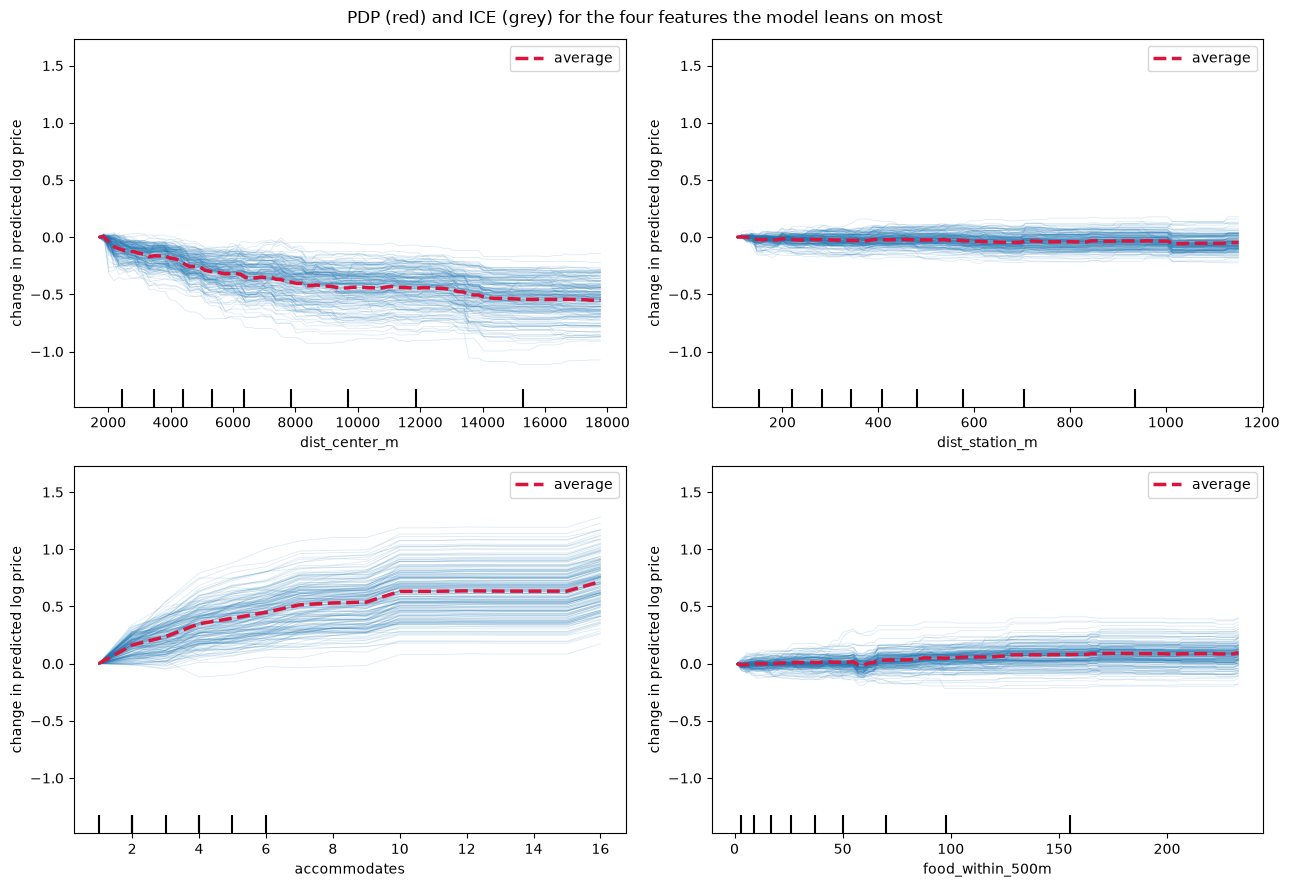

In [2]:
from sklearn.inspection import PartialDependenceDisplay

feats = ["dist_center_m", "dist_station_m", "accommodates", "food_within_500m"]

# the design matrix is float32 to save memory; PDP builds a float64 value grid
# and pandas refuses to place those values into float32 columns, so give PDP a
# float64 view. (Predicting on float64 is fine; sklearn casts internally.)
Xf = X.astype("float64")

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
PartialDependenceDisplay.from_estimator(
    gbr, Xf, feats,
    kind="both",              # both the average (PDP) and the per-listing lines (ICE)
    subsample=200,            # 200 ICE lines, enough to see the spread
    centered=True,            # start every ICE line at 0 so the SHAPE is comparable
    n_jobs=-1, random_state=0,
    ax=axes.ravel().tolist(),
    ice_lines_kw={"alpha": 0.15, "linewidth": 0.6},
    pd_line_kw={"color": "crimson", "linewidth": 2.5},
)
for ax in axes.ravel():
    ax.set_ylabel("change in predicted log price")
fig.suptitle("PDP (red) and ICE (grey) for the four features the model leans on most")
plt.tight_layout()

**What we see.**

- **`dist_center_m`:** a clear downward slope, roughly -0.5 in log price (about
  -40%) from the centre out to the edge, with a step down past ~14 km. The ICE
  lines fan out a lot: distance to the centre matters much more for some listings
  than others, which is the model using an interaction (it costs a central
  entire-home more to be pushed out than it costs an outer private room).
- **`dist_station_m`:** almost flat. This is the interesting one. Once the model
  knows how central a listing is (and which borough it is in), the *extra*
  average effect of walking distance to a station is close to zero. It does not
  mean the feature is useless: SHAP showed it contributes to individual
  predictions. It means `dist_center_m` and `dist_station_m` carry overlapping
  "how connected is this" information, and the model puts most of that weight on
  distance to the centre.
- **`accommodates`:** a clean, roughly monotonic rise, about +0.65 in log price
  (roughly doubling) from sleeps-1 to sleeps-10, then flattening. This is the
  single strongest driver and the shape makes sense.
- **`food_within_500m`:** a gentle positive slope of about +0.1 in log price
  (about +10%) that saturates. A real but second-order effect.

The `dist_station_m` result is a good example of why PDP is worth doing: a SHAP
bar or a linear coefficient would still show station distance "mattering", because
it does for individual listings, but the average marginal shape reveals that the
model has folded most of that signal into distance-to-centre.

## Part 2. Which listings does the model most disagree with?

### The idea

Run the model over every listing, compare its prediction to the real price, and
list the biggest gaps in each direction:

- **actual far above the prediction:** the model thinks this listing is priced
  ambitiously, or it is missing something the host can see (a view, a recent
  refit, a specific quiet street).
- **actual far below the prediction:** the model thinks this is a bargain, or the
  listing is a special case (a long-stay rate, a room mislabelled as a whole
  place).

Both readings are worth stating. "The model thinks X" is not "X is true". But a
host would want to look hard at anything the model flags as underpriced.

### Why out-of-fold predictions

If a listing was in the training set, the model has partly memorised it, and its
"gap" would understate the real disagreement. So we predict each listing with a
model trained on the *other* spatial folds, exactly the setup from notebook 03.

In [3]:
from londonrent.data import build_interim

folds = M.spatial_block_folds(frame["latitude"].to_numpy(),
                              frame["longitude"].to_numpy(), n_splits=5, seed=0)
oof = np.full(len(y), np.nan)
for tr, te in folds:
    m = M.make_model()
    m.fit(X.iloc[tr], y[tr])
    oof[te] = m.predict(X.iloc[te])

# the cold-start frame drops review columns; pull two of them back by id, only to
# filter for plausible listings (not for the model)
extra = build_interim().set_index("id")[["number_of_reviews", "minimum_nights"]]
d = frame[["id", "neighbourhood_cleansed", "room_type", "property_class",
           "accommodates", "bedrooms", "price"]].join(extra, on="id")
d["predicted"] = np.exp(oof).round(0)
d["gap_gbp"] = (d["price"] - d["predicted"]).round(0)          # + = dearer than model
d["gap_pct"] = (d["gap_gbp"] / d["price"]).round(2)

In [4]:
cols = ["neighbourhood_cleansed", "room_type", "accommodates", "bedrooms",
        "number_of_reviews", "price", "predicted", "gap_pct"]

# raw: price window only
raw = d[d["price"].between(40, 500)]
print(f"RAW ({len(raw):,} listings in the £40-£500 window)")
print("  most 'overpriced':", raw.sort_values("gap_pct", ascending=False).head(3)["gap_pct"].tolist())
print("  most 'bargain'   :", raw.sort_values("gap_pct").head(3)["gap_pct"].tolist())

# filtered: also require a real track record and a short minimum stay, so a monthly
# rate entered as nightly (minimum_nights ~ 28+) or a dead listing drops out
plaus = d[d["price"].between(40, 500)
          & (d["number_of_reviews"] >= 5)
          & (d["minimum_nights"] <= 7)].copy()
print(f"\\nFILTERED ({len(plaus):,} listings: >=5 reviews and minimum stay <=7 nights)")

print("\\n=== model says OVERPRICED (actual well above prediction) ===")
print(plaus.sort_values("gap_pct", ascending=False).head(10)[cols].to_string(index=False))
print("\\n=== model says UNDERPRICED / a bargain (actual well below prediction) ===")
print(plaus.sort_values("gap_pct").head(10)[cols].to_string(index=False))

RAW (54,044 listings in the £40-£500 window)
  most 'overpriced': [0.87, 0.87, 0.87]
  most 'bargain'   : [-9.59, -7.67, -7.3]
\nFILTERED (30,781 listings: >=5 reviews and minimum stay <=7 nights)
\n=== model says OVERPRICED (actual well above prediction) ===
neighbourhood_cleansed    room_type  accommodates  bedrooms  number_of_reviews   price  predicted  gap_pct
              Hounslow Private room             1       NaN                  5  342.67       46.0     0.87
              Hounslow Private room             1       NaN                  7   343.0       45.0     0.87
               Croydon Private room             2       NaN                 12   355.0       58.0     0.84
              Haringey Private room             2       NaN                 10   409.0       75.0     0.82
               Bromley Private room             2       NaN                 17   351.0       68.0     0.81
                Ealing Private room             2       NaN                 49   400.0       78.0 

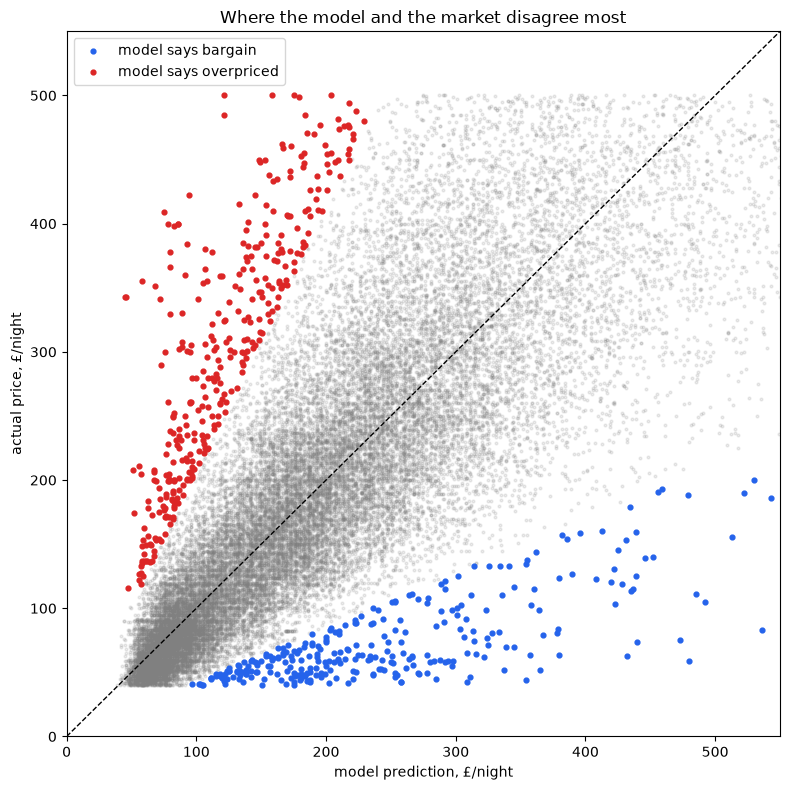

In [5]:
# the same thing as a picture: predicted vs actual, with the 1% most disagreed-with
# listings in each direction highlighted
lo = plaus["gap_pct"].quantile(0.01)
hi = plaus["gap_pct"].quantile(0.99)
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(plaus["predicted"], plaus["price"], s=4, alpha=.15, color="grey")
under = plaus[plaus["gap_pct"] <= lo]
over = plaus[plaus["gap_pct"] >= hi]
ax.scatter(under["predicted"], under["price"], s=12, color="#2563eb", label="model says bargain")
ax.scatter(over["predicted"], over["price"], s=12, color="#dc2626", label="model says overpriced")
lim = [0, 550]
ax.plot(lim, lim, "k--", lw=1)
ax.set(xlim=lim, ylim=lim, xlabel="model prediction, £/night",
       ylabel="actual price, £/night", title="Where the model and the market disagree most")
ax.legend()
plt.tight_layout()

**What we see.**

- **Raw scan** (price window only): both extremes are pure data-entry artefacts,
  gaps of 80% to 900%.
- **Filtered scan** (>= 5 reviews, minimum stay <= 7 nights): 30,781 of 54,000
  listings survive, and the extremes get *less* extreme but **not clean**. The
  "overpriced" list is still private rooms at £340 to £400 a night that the model
  prices at £45 to £86, some with 20 to 68 reviews. The "bargain" list is still
  Westminster entire flats at £45 to £60 a night with real review counts.
- So the filter removes the 500%-gap junk but **not** the listings whose stated
  nightly price does not match the product. A private room genuinely priced at
  £355 a night is either a real anomaly or a quirk the filter cannot catch (an old
  review history from when it was cheaper, a per-person price, a monthly rate).

**Honest read:** a "biggest gap" scan is a weak mispricing detector even with a
plausibility filter. A real one would flag listings whose price falls outside
*their own* prediction band (notebook 03), and would still need a human to look.

## Part 3. Why is Brent hard?

Notebook 03's error-by-borough check flagged **Brent**: about 25% median error on
555 test listings, worse than other well-sampled boroughs. Outer boroughs with few
listings are easy to explain away as a data-volume problem. Brent is not that. So
this is a short attempt to work out what is going on.

Three things to check:

1. Is the error **one-directional** (the model systematically under- or
   over-prices Brent) or just **noisy** (big errors both ways)?
2. Is Brent's price distribution **more spread out** than similar boroughs? A
   wider spread is harder to fit.
3. A hypothesis: **Wembley**. Brent contains Wembley Stadium and Arena. Prices
   near a major events venue spike on match and concert nights and are normal
   otherwise. The model has no date and no "near a venue" feature, so that
   event-driven variation is invisible to it and lands entirely in the error.

In [6]:
resid_pct = np.exp(oof) - frame["price"].to_numpy()
resid_pct = resid_pct / frame["price"].to_numpy()          # signed % error, per listing
brent = frame["neighbourhood_cleansed"].to_numpy() == "Brent"

peers = ["Ealing", "Harrow", "Barnet", "Hounslow", "Redbridge"]   # similar outer boroughs
peer_mask = np.isin(frame["neighbourhood_cleansed"].to_numpy(), peers)

print("1) direction of the error")
print(f"   Brent   median signed % error: {np.median(resid_pct[brent]):+.1%}"
      f"   (share over-predicted: {(resid_pct[brent] < 0).mean():.0%})")
print(f"   peers   median signed % error: {np.median(resid_pct[peer_mask]):+.1%}")

print("\\n2) spread of prices (coefficient of variation = std / mean)")
for name, mask in [("Brent", brent), ("peer boroughs", peer_mask), ("all in-scope", np.ones(len(frame), bool))]:
    p = frame["price"].to_numpy()[mask]
    print(f"   {name:16s} CV = {p.std() / p.mean():.2f}   median £{np.median(p):.0f}")

print("\\n3) distance to Wembley Stadium (51.556, -0.2796): are Brent's big misses clustered near it?")
from londonrent.geo import _points_to_bng_xy
xy = _points_to_bng_xy(frame["latitude"].to_numpy(), frame["longitude"].to_numpy())
wem = _points_to_bng_xy(np.array([51.556]), np.array([-0.2796]))[0]
dist_wem = np.hypot(xy[:, 0] - wem[0], xy[:, 1] - wem[1])
big_miss = brent & (np.abs(resid_pct) > 0.30)
print(f"   Brent listings within 2 km of Wembley: median |% error| "
      f"{np.median(np.abs(resid_pct[brent & (dist_wem < 2000)])):.0%}")
print(f"   Brent listings further than 2 km:      median |% error| "
      f"{np.median(np.abs(resid_pct[brent & (dist_wem >= 2000)])):.0%}")

1) direction of the error
   Brent   median signed % error: +6.6%   (share over-predicted: 44%)
   peers   median signed % error: +3.5%
\n2) spread of prices (coefficient of variation = std / mean)
   Brent            CV = 0.77   median £150
   peer boroughs    CV = 0.79   median £121
   all in-scope     CV = 0.76   median £178
\n3) distance to Wembley Stadium (51.556, -0.2796): are Brent's big misses clustered near it?


   Brent listings within 2 km of Wembley: median |% error| 26%
   Brent listings further than 2 km:      median |% error| 27%


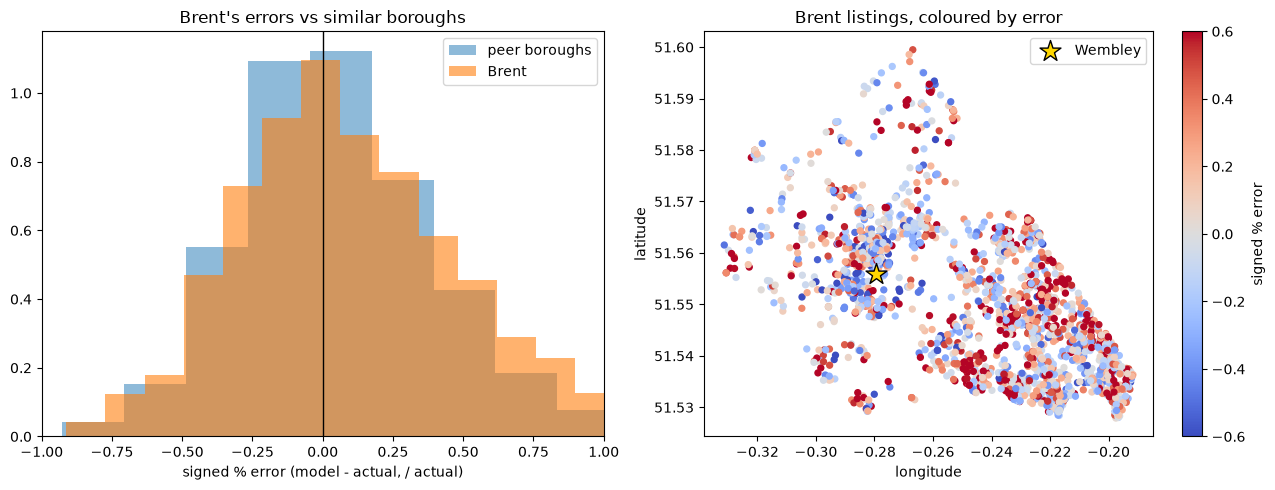

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].hist(resid_pct[peer_mask], bins=40, alpha=.5, label="peer boroughs", density=True)
ax[0].hist(resid_pct[brent], bins=40, alpha=.6, label="Brent", density=True)
ax[0].axvline(0, color="k", lw=1); ax[0].set(xlim=(-1, 1),
    xlabel="signed % error (model - actual, / actual)", title="Brent's errors vs similar boroughs")
ax[0].legend()

b = frame[brent]
sc = ax[1].scatter(b["longitude"], b["latitude"], c=np.clip(resid_pct[brent], -.6, .6),
                   cmap="coolwarm", s=18)
ax[1].scatter([-0.2796], [51.556], marker="*", s=250, color="gold", edgecolor="k", label="Wembley")
fig.colorbar(sc, ax=ax[1], label="signed % error"); ax[1].legend()
ax[1].set(xlabel="longitude", ylabel="latitude", title="Brent listings, coloured by error")
plt.tight_layout()

**What we see.** I formed three hypotheses and checked them. Two do not hold up.

1. **Direction:** Brent's median signed error is **+6.6%** (the model over-predicts
   a little), with 44% of listings over-predicted, so the error is close to
   balanced. There is a mild over-prediction lean but no strong systematic bias.
2. **Price spread:** Brent's coefficient of variation is **0.77**, the same as the
   peer boroughs (0.79) and the whole dataset (0.76). Brent's prices are **not**
   unusually spread out, so "wider spread" is not the explanation.
3. **Wembley:** the median absolute error is **26%** within 2 km of the stadium and
   **27%** further away. The big misses are **not** clustered near Wembley, so the
   events hypothesis gets no support from this check.

**Honest conclusion:** I could not pin down why Brent is harder. It is imprecise
rather than badly biased, its prices are not unusually spread, and the errors are
not concentrated near the obvious landmark. The next thing to try would be an
"is there a major venue nearby" feature and event-calendar data, neither of which
this dataset has. Reported as an open question, not a solved one.

## Takeaways

- **PDP and ICE** show sensible non-linear shapes and a surprise: the average
  marginal effect of distance to a *station* is close to flat once centrality is
  known, because the two features overlap and the model leans on distance-to-centre.
- **The disagreement scan** is a weak mispricing detector: raw, it finds only
  data-entry junk; filtered, it still surfaces listings whose nightly price does
  not match the product. A real detector needs the prediction band and a human.
- **Brent** stayed an open question. It is mildly over-predicted, its price spread
  is normal, and the errors are not concentrated near Wembley. I ruled out two
  explanations and did not confirm a third; the feature that would test the events
  idea is not in this dataset.